# **PREDIKSI KUNJUNGAN WISATAWAN DOMESTIK KE BALI TAHUN 2025**



## **KELOMPOK VCA**
Nama Anggota:
1. A.A. Istri Candra Manika Dewi  (2311110026)
2. Vania Noverina                 (2311110031)
3. Azka Widya Rahmawati           (2311110054)

### **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import boxcox

### **Data Wrangling**

#### **Load Dataset**

In [ ]:
# 1. Load Dataset
kunjungan_wisatawan = pd.read_csv('/content/Banyaknya Wisatawan Domestik Bulanan ke Bali, 2004-2024 (1).csv', header=None)

In [ ]:
kunjungan_wisatawan.head(20)

,0,1,2,3,4,5,6,7,8,9
0,Kunjungan Wisatawan Domestik ke Bali per Bulan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Number of Domestic Visitor to Bali by Month, 2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bulan,2004,2005,2006,2007,2008,2009,2010,2011,2012
4,Januari,167 106,174 515,202 857,181 266,225 955,264 915,349 575,280 588,333 199
5,Pebruari,133 660,161 808,161 413,144 425,190 792,204 419,238 789,340 508,305 934
6,Maret,118 369,194 411,171 795,161 009,221 181,255 203,202 995,358 313,307 616
7,April,129 730,174 033,192 182,165 509,206 631,247 100,396 898,385 228,331 378
8,Mei,142 186,190 855,188 152,183 736,226 339,289 635,421 369,463 452,525 076
9,Juni,167 718,201 990,204 284,214 957,256 448,304 213,455 456,568 264,569 635


#### **Memindahkan dan menggabungkan baris yang berisi bulan dan tahun menjadi kesamping (horizontal)**

In [ ]:
# 2. Cari otomatis baris yang berisi kata "Bulan"
header_indices = kunjungan_wisatawan[kunjungan_wisatawan[0] == 'Bulan'].index.tolist()
print(f"Header ditemukan di baris: {header_indices}") # Harusnya [3, 19, 35]

# 3. Fungsi pemotong blok data yang aman
def extract_block(kunjungan, start_row, num_rows, col_slice):
    # Ambil blok data (termasuk header)
    block = kunjungan.iloc[start_row : start_row + num_rows, col_slice].copy()

    # Set baris pertama sebagai nama kolom
    block.columns = block.iloc[0]

    # Hapus baris header dari data & reset index
    block = block[1:].reset_index(drop=True)

    # Membersihkan nama kolom
    new_cols = []
    for c in block.columns:
        if isinstance(c, float) and c.is_integer():
            new_cols.append(str(int(c))) # Ubah 2005.0 jadi "2005"
        else:
            new_cols.append(str(c))
    block.columns = new_cols

    return block

# 4. Ekstrak 3 Blok Data
# Blok 1: 2004-2012 (13 baris = 1 header + 12 bulan)
block1 = extract_block(kunjungan_wisatawan, header_indices[0], 13, slice(0, 10))

# Blok 2: 2013-2021
block2 = extract_block(kunjungan_wisatawan, header_indices[1], 13, slice(0, 10))

# Blok 3: 2022-2024 (Ambil 4 kolom pertama: Bulan, 2022, 2023, 2024)
block3 = extract_block(kunjungan_wisatawan, header_indices[2], 13, slice(0, 4))

# 5. Gabungkan (Merge) menyamping
kunjungan = block1.merge(block2, on='Bulan', how='left').merge(block3, on='Bulan', how='left')
kunjungan

Header ditemukan di baris: [3, 19, 35]


,Bulan,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Januari,167 106,174 515,202 857,181 266,225 955,264 915,349 575,280 588,333 199,...,528 506,597 558,658 308,743 456,793 527,879 702,282 248,527 447,720 164,774 529
1,Pebruari,133 660,161 808,161 413,144 425,190 792,204 419,238 789,340 508,305 934,...,483 221,513 852,520 462,655 719,692 113,721 105,240 608,389 690,629 282,726 744
2,Maret,118 369,194 411,171 795,161 009,221 181,255 203,202 995,358 313,307 616,...,503 311,576 438,618 834,762 622,787 616,567 452,305 579,547 726,665 751,612 742
3,April,129 730,174 033,192 182,165 509,206 631,247 100,396 898,385 228,331 378,...,528 668,534 395,705 710,777 287,795 997,175 120,330 593,500 740,900 880,1 124 781
4,Mei,142 186,190 855,188 152,183 736,226 339,289 635,421 369,463 452,525 076,...,651 089,647 790,646 467,682 521,656 082,101 948,363 959,960 692,943 713,852 253
5,Juni,167 718,201 990,204 284,214 957,256 448,304 213,455 456,568 264,569 635,...,571 646,1 035 563,659 718,1 156 151,1 287 877,137 395,498 852,753 907,883 793,898 335
6,Juli,212 463,254 264,245 909,244 032,329 362,340 610,489 307,573 103,524 334,...,799 765,1 084 950,890 368,906 347,935 930,229 112,166 718,784 205,898 260,926 975
7,Agustus,171 034,217 782,218 117,217 822,259 511,280 972,377 570,440 751,661 334,...,641 684,704 662,790 323,770 364,925 360,355 732,202 187,659 567,712 860,853 713
8,September,168 420,218 382,196 167,181 846,205 304,352 257,594 662,609 633,572 359,...,557 081,725 240,832 026,774 144,812 003,283 349,298 950,622 068,755 293,856 370
9,Oktober,150 827,168 684,238 721,299 724,306 112,330 337,391 722,526 302,667 703,...,619 599,685 244,732 720,762 124,853 007,337 304,468 826,718 066,813 745,828 647


### **Exploratory Data Analysis (EDA)**

In [ ]:
kunjungan.head()

,Bulan,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Januari,167 106,174 515,202 857,181 266,225 955,264 915,349 575,280 588,333 199,...,528 506,597 558,658 308,743 456,793 527,879 702,282 248,527 447,720 164,774 529
1,Pebruari,133 660,161 808,161 413,144 425,190 792,204 419,238 789,340 508,305 934,...,483 221,513 852,520 462,655 719,692 113,721 105,240 608,389 690,629 282,726 744
2,Maret,118 369,194 411,171 795,161 009,221 181,255 203,202 995,358 313,307 616,...,503 311,576 438,618 834,762 622,787 616,567 452,305 579,547 726,665 751,612 742
3,April,129 730,174 033,192 182,165 509,206 631,247 100,396 898,385 228,331 378,...,528 668,534 395,705 710,777 287,795 997,175 120,330 593,500 740,900 880,1 124 781
4,Mei,142 186,190 855,188 152,183 736,226 339,289 635,421 369,463 452,525 076,...,651 089,647 790,646 467,682 521,656 082,101 948,363 959,960 692,943 713,852 253


In [ ]:
kunjungan.tail()

,Bulan,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
7,Agustus,171 034,217 782,218 117,217 822,259 511,280 972,377 570,440 751,661 334,...,641 684,704 662,790 323,770 364,925 360,355 732,202 187,659 567,712 860,853 713
8,September,168 420,218 382,196 167,181 846,205 304,352 257,594 662,609 633,572 359,...,557 081,725 240,832 026,774 144,812 003,283 349,298 950,622 068,755 293,856 370
9,Oktober,150 827,168 684,238 721,299 724,306 112,330 337,391 722,526 302,667 703,...,619 599,685 244,732 720,762 124,853 007,337 304,468 826,718 066,813 745,828 647
10,Nopember,269 132,259 543,234 308,204 579,203 416,285 526,361 395,574 016,545 348,...,529 381,655 962,741 649,806 397,852 626,425 097,513 482,657 949,749 268,724 560
11,Desember,207 541,192 242,220 882,285 739,267 742,365 948,366 605,554 963,719 642,...,733 149,882 026,939 048,960 859,1 152 901,382 841,629 590,930 917,1 204 902,941 137


In [ ]:
kunjungan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Bulan   12 non-null     object
 1   2004    12 non-null     object
 2   2005    12 non-null     object
 3   2006    12 non-null     object
 4   2007    12 non-null     object
 5   2008    12 non-null     object
 6   2009    12 non-null     object
 7   2010    12 non-null     object
 8   2011    12 non-null     object
 9   2012    12 non-null     object
 10  2013    12 non-null     object
 11  2014    12 non-null     object
 12  2015    12 non-null     object
 13  2016    12 non-null     object
 14  2017    12 non-null     object
 15  2018    12 non-null     object
 16  2019    12 non-null     object
 17  2020    12 non-null     object
 18  2021    12 non-null     object
 19  2022    12 non-null     object
 20  2023    12 non-null     object
 21  2024    12 non-null     object
dtypes: object(22)
memory usage: 

#### **Melihat jumlah baris dan kolom pada dataset**

In [ ]:
kunjungan.shape

(12, 22)

#### **Mencari missing value pada dataset**

In [ ]:
kunjungan.isna().sum()

,0
Bulan,0
2004,0
2005,0
2006,0
2007,0
2008,0
2009,0
2010,0
2011,0
2012,0


In [ ]:
kunjungan.isnull().sum()

,0
Bulan,0
2004,0
2005,0
2006,0
2007,0
2008,0
2009,0
2010,0
2011,0
2012,0


Setelah dilakukan pencarian missing values menggunakan `isna()` dan `isnull()`, tidak ditemukan adanya missing values pada dataset, sehingga tidak perlu dilakukan handling missing values.

#### **Mencari data yang terduplikat**

In [ ]:
kunjungan.duplicated().sum()

np.int64(0)

Tidak ditemukan data yang terduplikat pada dataset, sehingga tidak diperlukan handling duplicated data.

#### **Melihat statistika deskriptif**

In [ ]:
kunjungan.describe()

,Bulan,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,12,12,12,12,12,12,12,12,12,12,...,12,12,12,12,12,12,12,12,12,12
unique,12,12,12,12,12,12,12,12,12,12,...,12,12,12,12,12,12,12,12,12,12
top,Januari,167 106,174 515,202 857,181 266,225 955,264 915,349 575,280 588,333 199,...,528 506,597 558,658 308,743 456,793 527,879 702,282 248,527 447,720 164,774 529
freq,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


#### **Mencari nilai Max**

In [ ]:
hasil = {}
# Mencari bulan dengan kunjungan terbanyak dalam 1 tahun
for tahun in kunjungan.columns[1:]:
    # nilai max
    max_value = kunjungan[tahun].max()
    # ambil bulan terkait
    bulan_max = kunjungan.loc[kunjungan[tahun].idxmax(), "Bulan"]
    # simpan ke dict
    hasil[tahun] = f"{bulan_max} = {max_value:}"

# Output
for th, info in hasil.items():
    print(f"{th} → {info}")

2004 → Nopember =  269 132
2005 → Nopember =  259 543
2006 → Juli =  245 909
2007 → Oktober =  299 724
2008 → Juli =  329 362
2009 → Desember =  365 948
2010 → September =  594 662
2011 → September =  609 633
2012 → Desember =  719 642
2013 → Agustus =  878 278
2014 → Agustus =  843 958
2015 → Juli =  799 765
2016 → Juli = 1 084 950
2017 → Desember =  939 048
2018 → Juni = 1 156 151
2019 → Juni = 1 287 877
2020 → Januari =  879 702
2021 → Desember =  629 590
2022 → Mei =  960 692
2023 → Desember = 1 204 902
2024 → April = 1 124 781


#### **Plot Time Series**

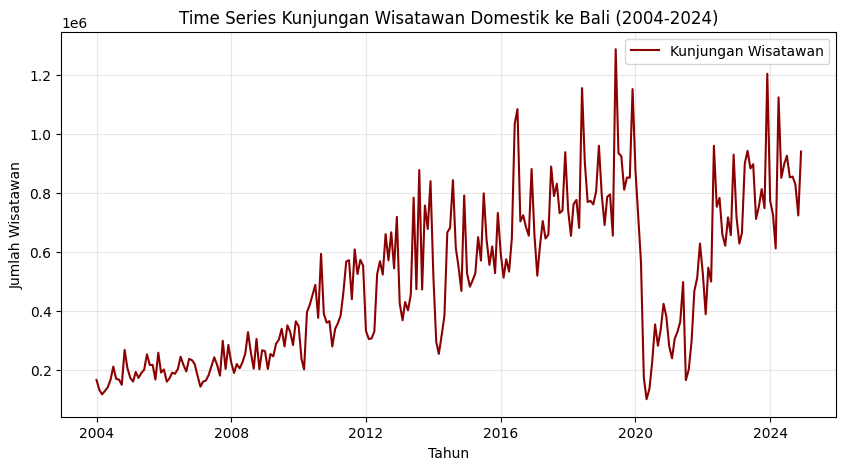

In [ ]:
# 6. Transform data for time series analysis
# Convert all columns from '2004' to '2024' to numeric, handling spaces and commas
for col in kunjungan.columns[1:]:
    kunjungan[col] = kunjungan[col].astype(str).str.replace(' ', '').str.replace(',', '', regex=False).astype(int)

# Melt the DataFrame to long format
kunjungan_long = kunjungan.melt(id_vars=['Bulan'], var_name='Tahun', value_name='Jumlah Kunjungan')

# Create a 'Tanggal' (Date) column
kunjungan_long['Tanggal'] = kunjungan_long['Bulan'] + ' ' + kunjungan_long['Tahun']

# Convert 'Tanggal' to datetime objects, setting day to 1 for consistency
# Handle month names in Indonesian
month_mapping = {
    'Januari': '01',
    'Pebruari': '02',
    'Maret': '03',
    'April': '04',
    'Mei': '05',
    'Juni': '06',
    'Juli': '07',
    'Agustus': '08',
    'September': '09',
    'Oktober': '10',
    'Nopember': '11',
    'Desember': '12'
}
kunjungan_long['Tanggal'] = kunjungan_long['Tanggal'].replace(month_mapping, regex=True)
kunjungan_long['Tanggal'] = pd.to_datetime(kunjungan_long['Tanggal'], format='%m %Y')

# Set 'Tanggal' as index and sort
kunjungan_long = kunjungan_long.set_index('Tanggal').sort_index()

# Create the series for time series analysis
series = kunjungan_long['Jumlah Kunjungan']

plt.figure(figsize=(10, 5))
plt.plot(series, label='Kunjungan Wisatawan', color='darkred')
plt.title('Time Series Kunjungan Wisatawan Domestik ke Bali (2004-2024)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Pre-Processing**

#### **Uji Stasioneritas**

##### **ACF dan PACF**

<Figure size 1200x400 with 0 Axes>

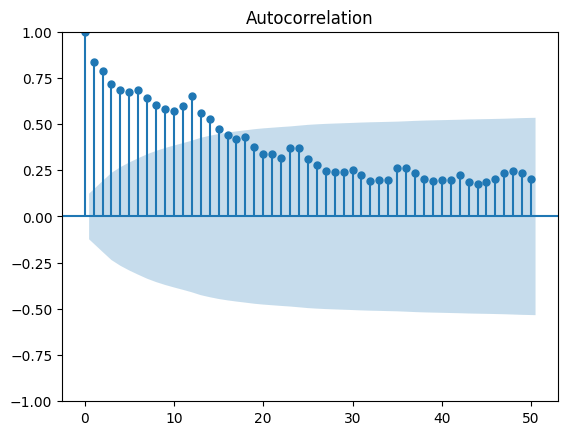

<Figure size 1200x400 with 0 Axes>

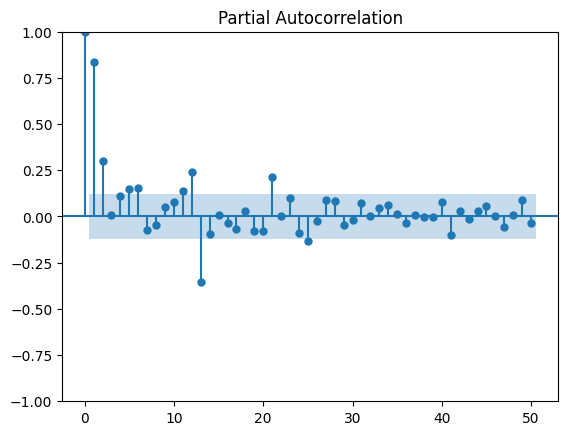

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(series, lags=50)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(series, lags=50, method='ywm')
plt.show()

In [ ]:
result = adfuller(series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -1.5463571926417838
p-value: 0.510467309831907
Critical Values:
   1%: -3.458010773719797
   5%: -2.8737103617125186
   10%: -2.5732559963936206


##### **Boxcox**

Estimated lambda for Box-Cox: 0.3336132065074772


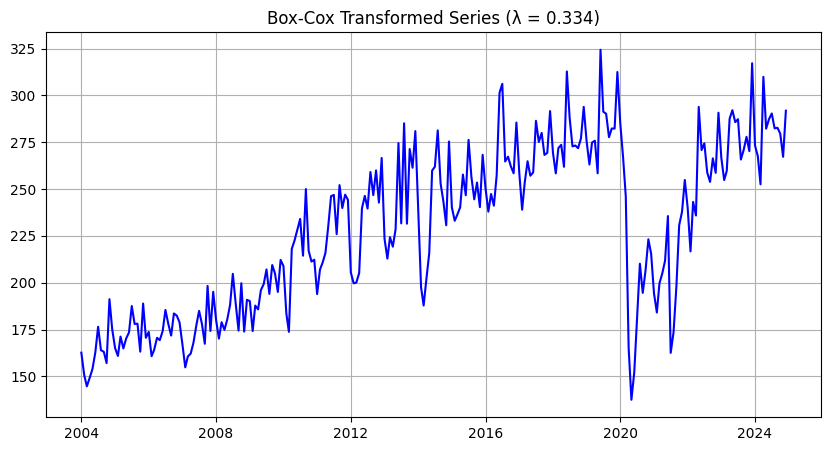

In [ ]:
ts_positive = series
ts_boxcox, lambda_bc = boxcox(ts_positive)

print("Estimated lambda for Box-Cox:", lambda_bc)

plt.figure(figsize=(10,5))
plt.plot(series.index, ts_boxcox, color='blue')
plt.title(f"Box-Cox Transformed Series (λ = {lambda_bc:.3f})")
plt.grid(True)
plt.show()

### **Penanganan Stasioneritas**

#### **1. Differencing 1 kali**

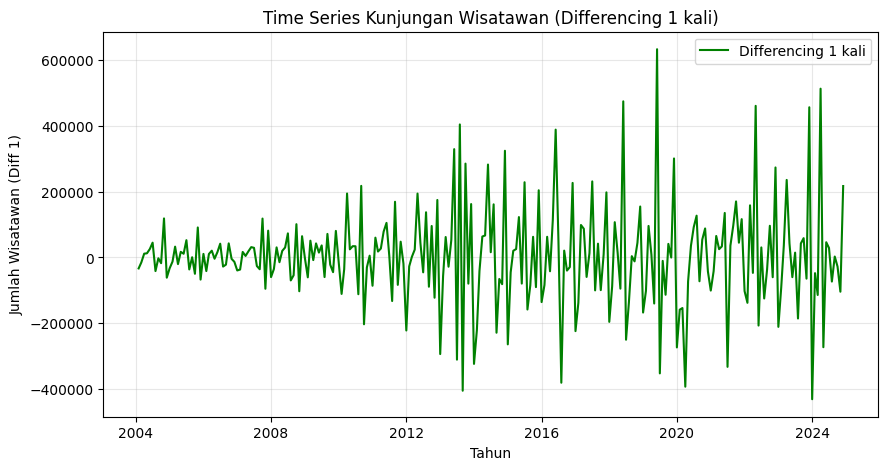

ADF Statistic (Differencing 1 kali): -5.52492093496906
p-value (Differencing 1 kali): 1.8419363850209904e-06
Critical Values (Differencing 1 kali):
   1%: -3.458010773719797
   5%: -2.8737103617125186
   10%: -2.5732559963936206


<Figure size 1200x400 with 0 Axes>

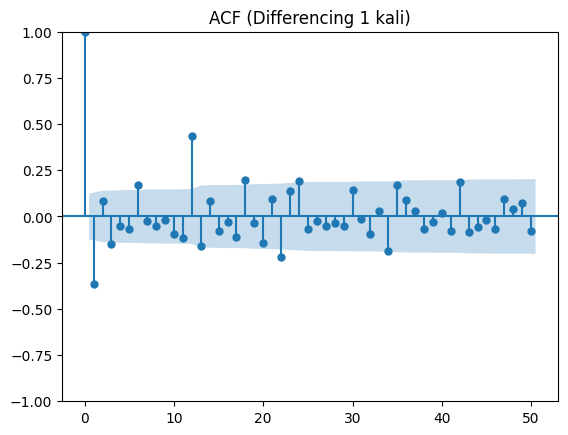

<Figure size 1200x400 with 0 Axes>

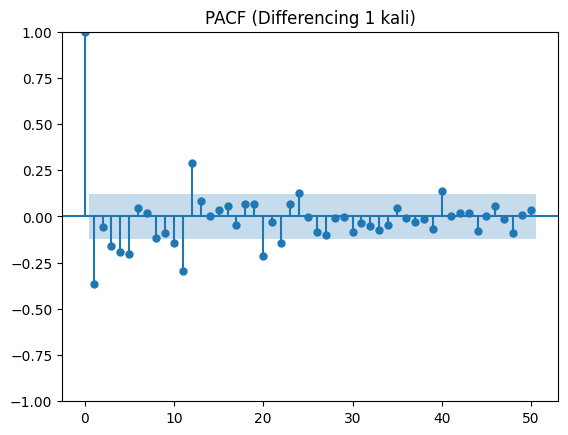

In [ ]:
import matplotlib.pyplot as plt

# Differencing 1 kali
diff1_series = series.diff().dropna()

plt.figure(figsize=(10, 5))
plt.plot(diff1_series, label='Differencing 1 kali', color='green')
plt.title('Time Series Kunjungan Wisatawan (Differencing 1 kali)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Wisatawan (Diff 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ADF test for diff1_series
result_diff1 = adfuller(diff1_series)
print("ADF Statistic (Differencing 1 kali):", result_diff1[0])
print("p-value (Differencing 1 kali):", result_diff1[1])
print("Critical Values (Differencing 1 kali):")
for key, value in result_diff1[4].items():
    print(f"   {key}: {value}")

# ACF and PACF for diff1_series
plt.figure(figsize=(12,4))
plot_acf(diff1_series, lags=50, title='ACF (Differencing 1 kali)')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(diff1_series, lags=50, method='ywm', title='PACF (Differencing 1 kali)')
plt.show()

#### **2. Differencing 2 kali**

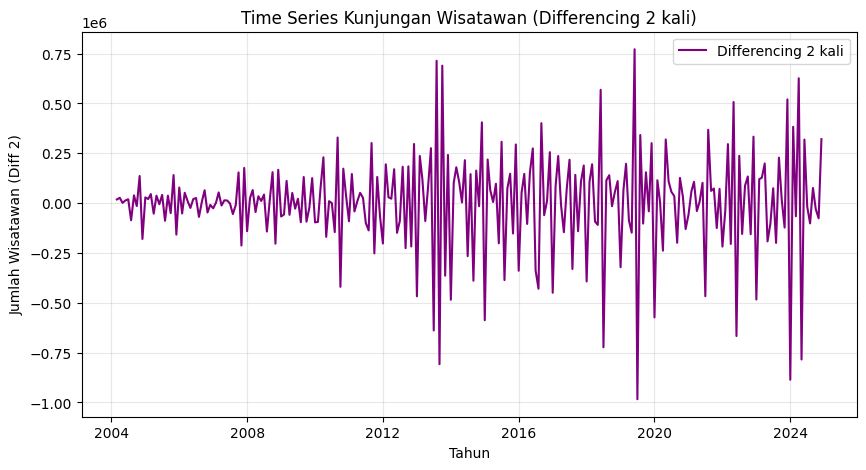

ADF Statistic (Differencing 2 kali): -7.71913261988327
p-value (Differencing 2 kali): 1.2057234488139094e-11
Critical Values (Differencing 2 kali):
   1%: -3.458731141928624
   5%: -2.8740258764297293
   10%: -2.5734243167124093


<Figure size 1200x400 with 0 Axes>

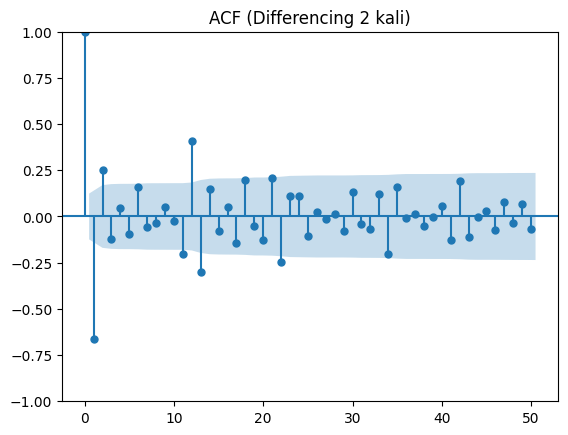

<Figure size 1200x400 with 0 Axes>

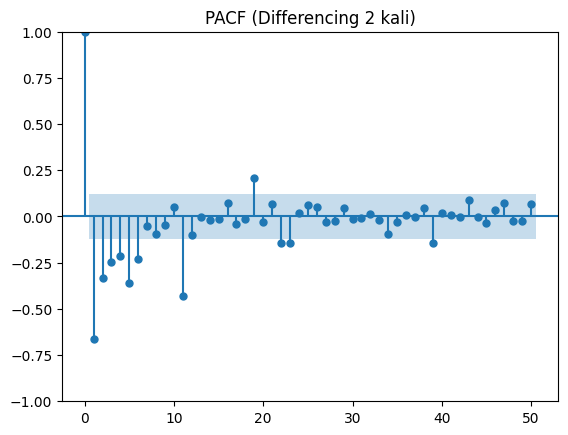

In [ ]:
import matplotlib.pyplot as plt

# Differencing 2 kali
diff2_series = series.diff().diff().dropna()

plt.figure(figsize=(10, 5))
plt.plot(diff2_series, label='Differencing 2 kali', color='purple')
plt.title('Time Series Kunjungan Wisatawan (Differencing 2 kali)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Wisatawan (Diff 2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ADF test for diff2_series
result_diff2 = adfuller(diff2_series)
print("ADF Statistic (Differencing 2 kali):", result_diff2[0])
print("p-value (Differencing 2 kali):", result_diff2[1])
print("Critical Values (Differencing 2 kali):")
for key, value in result_diff2[4].items():
    print(f"   {key}: {value}")

# ACF and PACF for diff2_series
plt.figure(figsize=(12,4))
plot_acf(diff2_series, lags=50, title='ACF (Differencing 2 kali)')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(diff2_series, lags=50, method='ywm', title='PACF (Differencing 2 kali)')
plt.show()

#### **3. Transformasi Log**

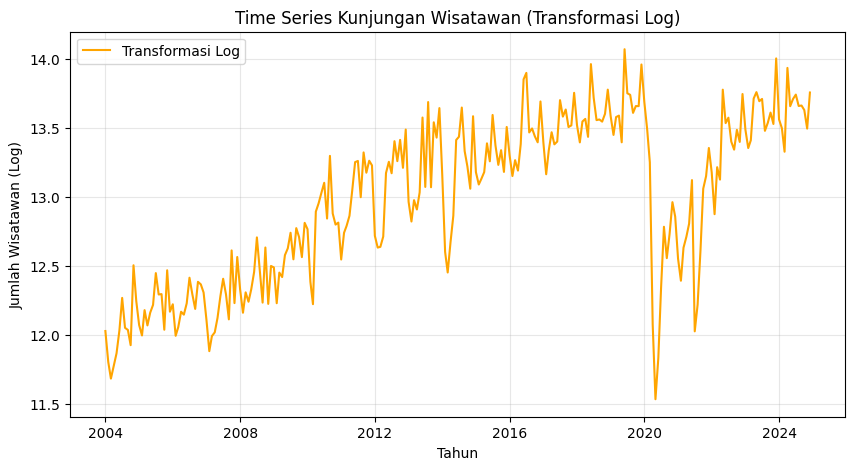

ADF Statistic (Transformasi Log): -1.670510022377682
p-value (Transformasi Log): 0.44636704297700186
Critical Values (Transformasi Log):
   1%: -3.458010773719797
   5%: -2.8737103617125186
   10%: -2.5732559963936206


<Figure size 1200x400 with 0 Axes>

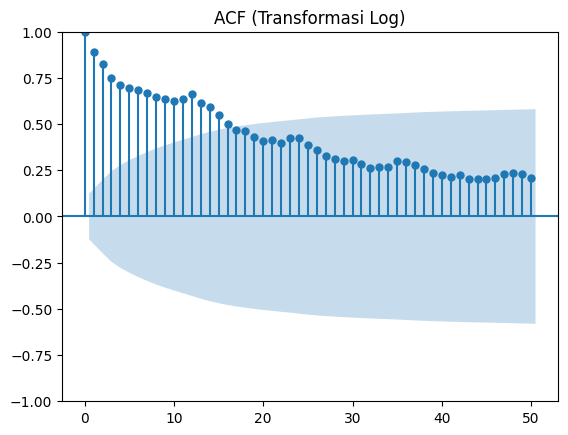

<Figure size 1200x400 with 0 Axes>

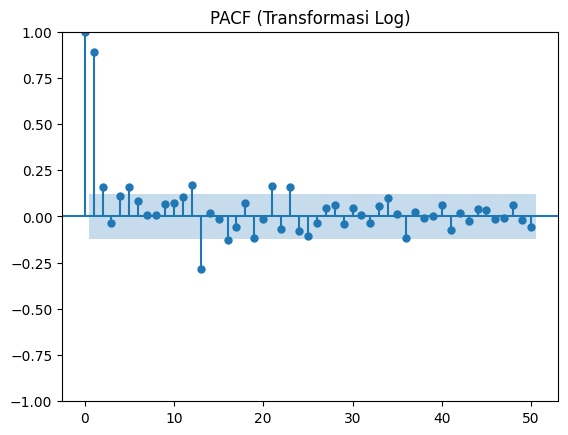

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Transformasi Log
log_series = np.log(series)

plt.figure(figsize=(10, 5))
plt.plot(log_series, label='Transformasi Log', color='orange')
plt.title('Time Series Kunjungan Wisatawan (Transformasi Log)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Wisatawan (Log)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ADF test for log_series
result_log = adfuller(log_series)
print("ADF Statistic (Transformasi Log):", result_log[0])
print("p-value (Transformasi Log):", result_log[1])
print("Critical Values (Transformasi Log):")
for key, value in result_log[4].items():
    print(f"   {key}: {value}")

# ACF and PACF for log_series
plt.figure(figsize=(12,4))
plot_acf(log_series, lags=50, title='ACF (Transformasi Log)')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(log_series, lags=50, method='ywm', title='PACF (Transformasi Log)')
plt.show()

#### **4. Transformasi Log + Differencing 1 kali**

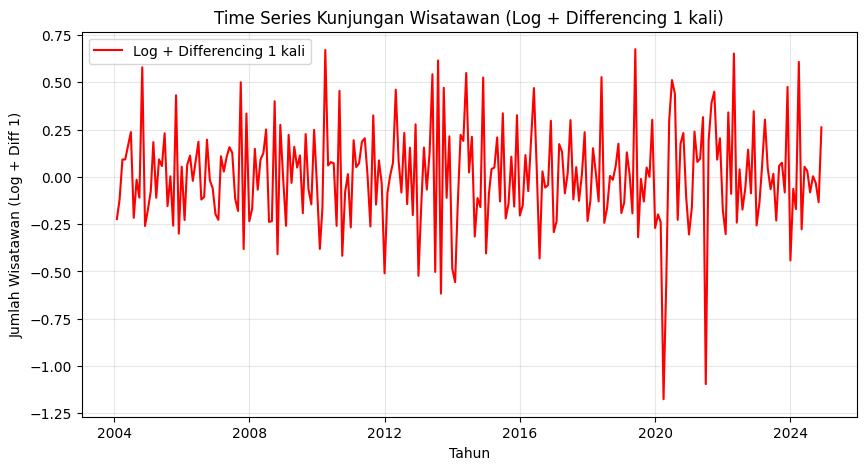

ADF Statistic (Log + Differencing 1 kali): -5.826931219372673
p-value (Log + Differencing 1 kali): 4.058751633926338e-07
Critical Values (Log + Differencing 1 kali):
   1%: -3.458010773719797
   5%: -2.8737103617125186
   10%: -2.5732559963936206


<Figure size 1200x400 with 0 Axes>

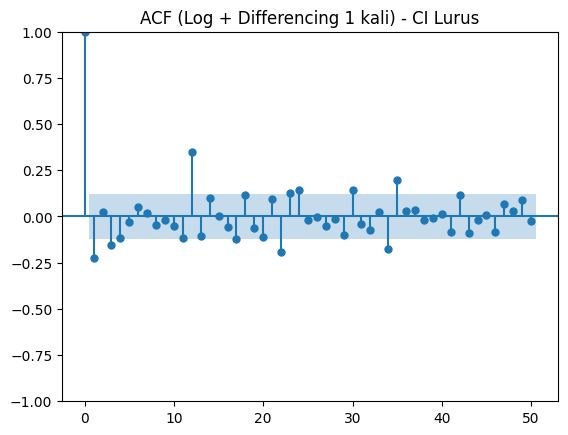

<Figure size 1200x400 with 0 Axes>

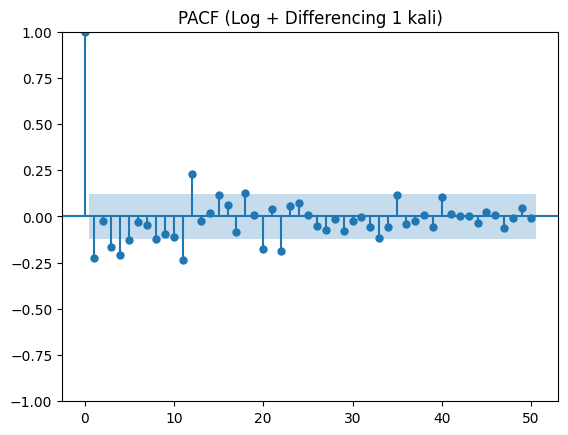

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Transformasi Log + Differencing 1 kali
log_diff1_series = np.log(series).diff().dropna()

plt.figure(figsize=(10, 5))
plt.plot(log_diff1_series, label='Log + Differencing 1 kali', color='red')
plt.title('Time Series Kunjungan Wisatawan (Log + Differencing 1 kali)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Wisatawan (Log + Diff 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ADF test for log_diff1_series
result_log_diff1 = adfuller(log_diff1_series)
print("ADF Statistic (Log + Differencing 1 kali):", result_log_diff1[0])
print("p-value (Log + Differencing 1 kali):", result_log_diff1[1])
print("Critical Values (Log + Differencing 1 kali):")
for key, value in result_log_diff1[4].items():
    print(f"   {key}: {value}")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plot_acf(
    log_diff1_series.dropna(),
    lags=50,
    alpha=0.05,
    bartlett_confint=False,   # <-- bikin band CI lurus/konstan
    title='ACF (Log + Differencing 1 kali) - CI Lurus'
)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(
    log_diff1_series.dropna(),
    lags=50,
    alpha=0.05,
    method='ywm',
    title='PACF (Log + Differencing 1 kali)'
)
plt.show()


#### **5. Transformasi Log + Differencing 2 kali**

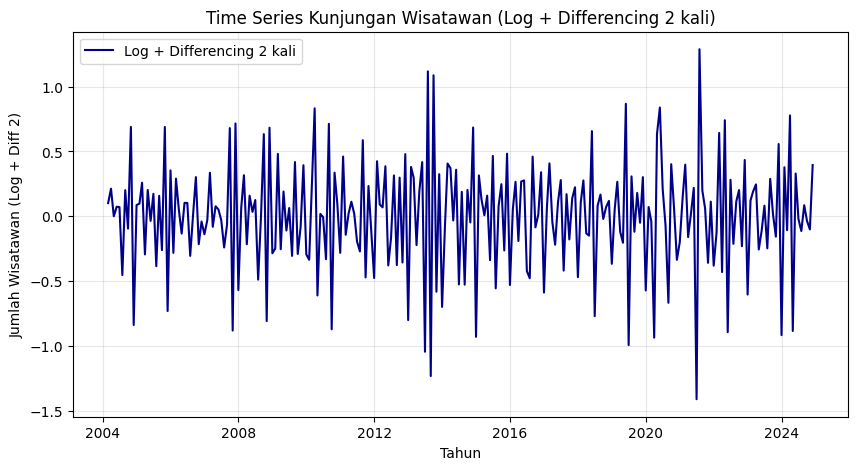

ADF Statistic (Log + Differencing 2 kali): -8.341446368965169
p-value (Log + Differencing 2 kali): 3.168081145068217e-13
Critical Values (Log + Differencing 2 kali):
   1%: -3.458731141928624
   5%: -2.8740258764297293
   10%: -2.5734243167124093


<Figure size 1200x400 with 0 Axes>

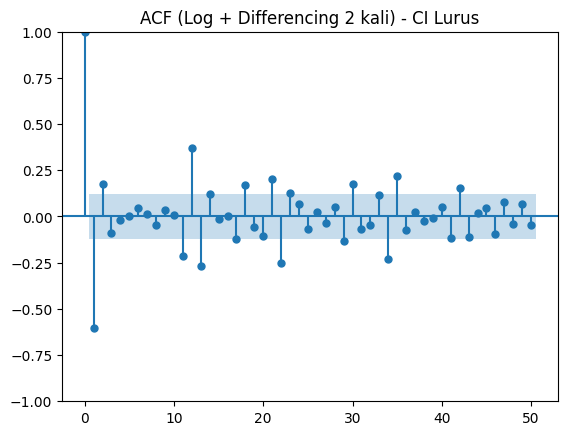

<Figure size 1200x400 with 0 Axes>

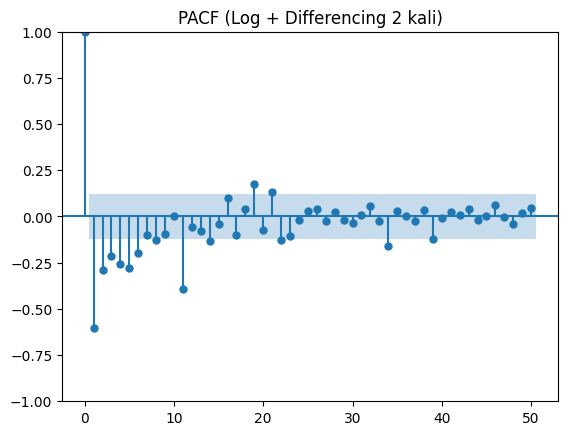

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Transformasi Log + Differencing 2 kali
log_diff2_series = np.log(series).diff().diff().dropna()

plt.figure(figsize=(10, 5))
plt.plot(log_diff2_series, label='Log + Differencing 2 kali', color='darkblue')
plt.title('Time Series Kunjungan Wisatawan (Log + Differencing 2 kali)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Wisatawan (Log + Diff 2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ADF test for log_diff2_series
result_log_diff2 = adfuller(log_diff2_series)
print("ADF Statistic (Log + Differencing 2 kali):", result_log_diff2[0])
print("p-value (Log + Differencing 2 kali):", result_log_diff2[1])
print("Critical Values (Log + Differencing 2 kali):")
for key, value in result_log_diff2[4].items():
    print(f"   {key}: {value}")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF and PACF for log_diff2_series (CI ACF lurus)
plt.figure(figsize=(12,4))
plot_acf(
    log_diff2_series.dropna(),
    lags=50,
    alpha=0.05,
    bartlett_confint=False,   # <-- bikin band CI lurus/konstan
    title='ACF (Log + Differencing 2 kali) - CI Lurus'
)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(
    log_diff2_series.dropna(),
    lags=50,
    alpha=0.05,
    method='ywm',
    title='PACF (Log + Differencing 2 kali)'
)
plt.show()

# **SARIMA DIFF 1**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Daftar kandidat model SARIMA dengan d=1, D=1, m=12
candidate_orders = [
    ("Kandidat_A", (1,1,1), (0,1,1,12)),
    ("Kandidat_B", (1,1,0), (1,1,1,12)),
    ("Kandidat_C", (2,1,1), (0,1,1,12)),
    ("Kandidat_D", (0,1,1), (1,1,1,12)),
    ("Kandidat_E", (1,1,1), (1,1,0,12)),
]

y_log = np.log(series)  # gunakan log series asli untuk fitting

results = {}
for name, order, seasonal_order in candidate_orders:
    try:
        model = SARIMAX(y_log,
                        order=order,
                        seasonal_order=seasonal_order,
                        trend="n",
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        res = model.fit(disp=False)
        results[name] = (res, order, seasonal_order)
        print(f"{name} | order={order} seasonal={seasonal_order} | AIC={res.aic:.3f} | BIC={res.bic:.3f}")
    except Exception as e:
        print(f"{name} gagal fit: {e}")

# Pilih model terbaik berdasarkan AIC terkecil
best_name, (best_res, best_order, best_seasonal_order) = min(results.items(), key=lambda kv: kv[1][0].aic)

print("\nMODEL TERBAIK (AIC TERKECIL)")
print("Best model:", best_name)
print("Order:", best_order)
print("Seasonal Order:", best_seasonal_order)
print(best_res.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_A | order=(1, 1, 1) seasonal=(0, 1, 1, 12) | AIC=23.325 | BIC=36.990


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_B | order=(1, 1, 0) seasonal=(1, 1, 1, 12) | AIC=25.441 | BIC=39.123


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_C | order=(2, 1, 1) seasonal=(0, 1, 1, 12) | AIC=32.951 | BIC=50.032


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_D | order=(0, 1, 1) seasonal=(1, 1, 1, 12) | AIC=24.981 | BIC=38.645


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_E | order=(1, 1, 1) seasonal=(1, 1, 0, 12) | AIC=70.108 | BIC=83.790

MODEL TERBAIK (AIC TERKECIL)
Best model: Kandidat_A
Order: (1, 1, 1)
Seasonal Order: (0, 1, 1, 12)
                                     SARIMAX Results                                      
Dep. Variable:                   Jumlah Kunjungan   No. Observations:                  252
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                  -7.663
Date:                            Fri, 02 Jan 2026   AIC                             23.325
Time:                                    12:30:13   BIC                             36.990
Sample:                                01-01-2004   HQIC                            28.840
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------

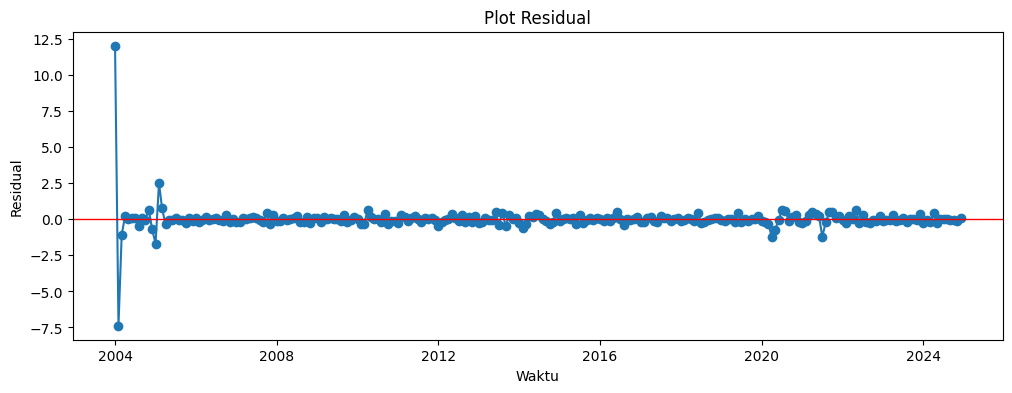

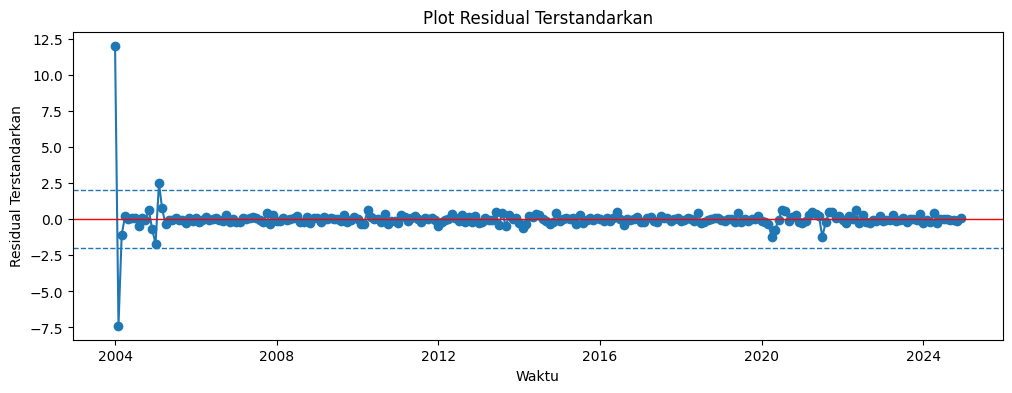

In [ ]:
# 1) Plot residual
plt.figure(figsize=(12,4))
plt.plot(resid, marker="o", linestyle="-")
plt.axhline(0, color="red", linewidth=1)
plt.title("Plot Residual")
plt.xlabel("Waktu")
plt.ylabel("Residual")
plt.show()

# 2) Plot residual terstandarkan
std_resid = resid / np.sqrt(best_res.scale)
plt.figure(figsize=(12,4))
plt.plot(std_resid, marker="o", linestyle="-")
plt.axhline(0, color="red", linewidth=1)
plt.axhline(2, linestyle="--", linewidth=1)
plt.axhline(-2, linestyle="--", linewidth=1)
plt.title("Plot Residual Terstandarkan")
plt.xlabel("Waktu")
plt.ylabel("Residual Terstandarkan")
plt.show()

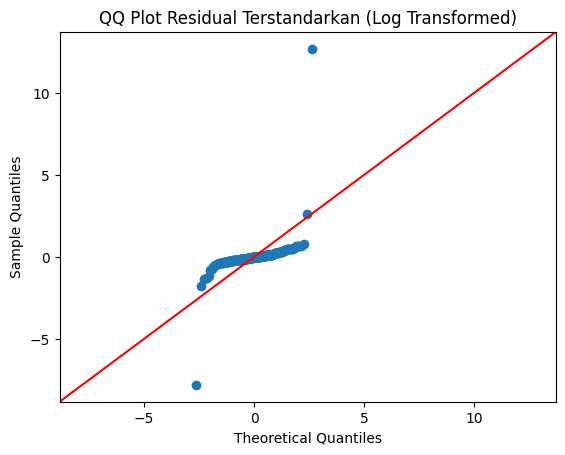

In [ ]:
# QQ Plot Residual
sm.qqplot(resid.dropna()/np.sqrt(res.scale), line="45", fit=True)
plt.title("QQ Plot Residual Terstandarkan (Log Transformed)")
plt.show()

In [ ]:
# Ljung-Box Test
lb = acorr_ljungbox(resid.dropna(), lags=[12,24,36], return_df=True)
print("Ljung-Box Test (lag 12,24,36):")
print(lb)

Ljung-Box Test (lag 12,24,36):
      lb_stat  lb_pvalue
12  46.584634   0.000006
24  51.115927   0.001019
36  51.448916   0.045812


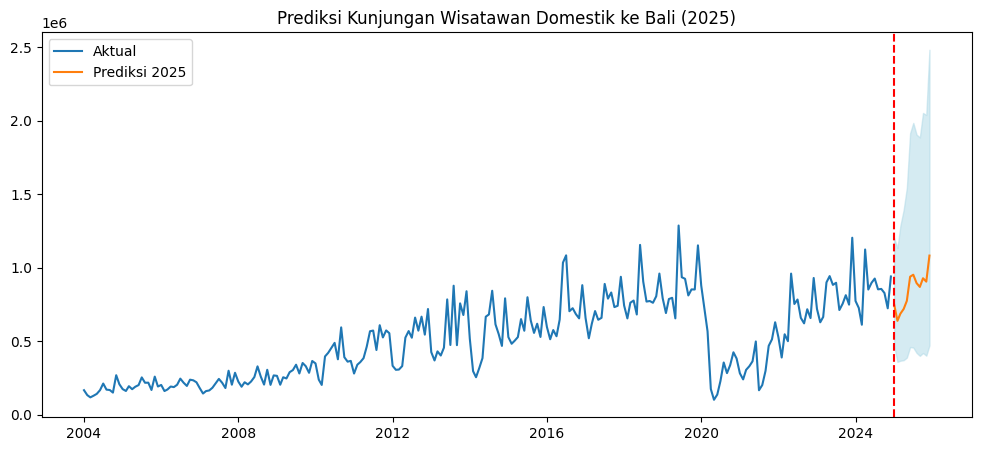

In [ ]:
# Forecast 12 Bulan ke Depan
n_steps = 12
fc = best_res.get_forecast(steps=n_steps)
pred_log = fc.predicted_mean
ci_log = fc.conf_int()

# Transformasi balik ke skala asli
pred = np.exp(pred_log)
lower = np.exp(ci_log.iloc[:,0])
upper = np.exp(ci_log.iloc[:,1])

plt.figure(figsize=(12,5))
plt.plot(series, label="Aktual")
plt.plot(pred, label="Prediksi 2025")
plt.fill_between(pred.index, lower, upper, color="lightblue", alpha=0.5)
plt.axvline(pred.index[0], color="red", linestyle="--")
plt.legend()
plt.title("Prediksi Kunjungan Wisatawan Domestik ke Bali (2025)")
plt.show()


In [ ]:
# Split data: menggunakan 12 bulan terakhir sebagai test set
test_size = 12
y_train_log = y_log.iloc[:-test_size]   # data log sebelum 2024
y_test_log  = y_log.iloc[-test_size:]   # data log tahun 2024

# Fit ulang model terbaik dengan data train
model = SARIMAX(y_train_log,
                order=best_order,
                seasonal_order=best_seasonal_order,
                trend="n",
                enforce_stationarity=False,
                enforce_invertibility=False)
res = model.fit(disp=False)

# Forecast sepanjang periode test (dalam skala log)
fc_log = res.get_forecast(steps=len(y_test_log))
y_pred_log = fc_log.predicted_mean
y_pred_log.index = y_test_log.index

# Transformasi balik ke skala asli
y_test_actual = np.exp(y_test_log)
y_pred_actual = np.exp(y_pred_log)

# Hitung metrik akurasi
mae = np.mean(np.abs(y_test_actual - y_pred_actual))
rmse = np.sqrt(np.mean((y_test_actual - y_pred_actual)**2))
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
smape = np.mean(2 * np.abs(y_test_actual - y_pred_actual) /
                (np.abs(y_test_actual) + np.abs(y_pred_actual))) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE (%):", mape)
print("sMAPE (%):", smape)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE : 127556.53997276875
RMSE: 161729.80290001706
MAPE (%): 14.915008134054828
sMAPE (%): 14.428552982159419


# **SARIMA DIFF 2**

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

m = 12  # periode musiman (bulanan biasanya 12).

# Input ke SARIMAX harus log_series karena kita memilih transformasi log
y_sarima_input = log_series

# Kandidat Orde SARIMA berdasarkan analisis ACF/PACF dari log_diff2_series (d=2, D=0)
candidate_orders = [
    ("Kandidat_A", (0, 2, 2), (0, 0, 1, m)),
    ("Kandidat_B", (1, 2, 1), (1, 0, 1, m)),
    ("Kandidat_C", (2, 2, 1), (0, 0, 2, m)),
    ("Kandidat_D", (2, 2, 2), (1, 0, 2, m)),
]

def fit_sarima(y, order, seasonal_order):
    model = SARIMAX(
        y,
        order=order,
        seasonal_order=seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False, maxiter=500) # Menaikkan maxiter untuk model yang lebih kompleks
    return res

results = {}
for name, order, seasonal_order in candidate_orders:
    try:
        res = fit_sarima(y_sarima_input, order=order, seasonal_order=seasonal_order)
        results[name] = res
        print(f"{name} | order={order} seasonal={seasonal_order} | AIC={res.aic:.3f} | BIC={res.bic:.3f}")
    except Exception as e:
        print(f"{name} GAGAL fit: {e}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_A | order=(0, 2, 2) seasonal=(0, 0, 1, 12) | AIC=32.157 | BIC=45.995


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_B | order=(1, 2, 1) seasonal=(1, 0, 1, 12) | AIC=23.872 | BIC=41.191


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_C | order=(2, 2, 1) seasonal=(0, 0, 2, 12) | AIC=34.225 | BIC=54.695


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kandidat_D | order=(2, 2, 2) seasonal=(1, 0, 2, 12) | AIC=37.451 | BIC=64.708


In [ ]:
if len(results) == 0:
    raise RuntimeError("Tidak ada model yang berhasil di-fit. Cek data y, frekuensi, atau parameter.")

best_name, best_res = min(results.items(), key=lambda kv: kv[1].aic)

# Retrieve the order and seasonal order from the candidate_orders list
chosen_order = None
chosen_seasonal_order = None
for name, order, seasonal_order in candidate_orders:
    if name == best_name:
        chosen_order = order
        chosen_seasonal_order = seasonal_order
        break

print("\nMODEL TERBAIK (AIC TERKECIL) ")
print("Best model:", best_name)
print("Order:", chosen_order)
print("Seasonal Order:", chosen_seasonal_order)
print(best_res.summary())


MODEL TERBAIK (AIC TERKECIL) 
Best model: Kandidat_B
Order: (1, 2, 1)
Seasonal Order: (1, 0, 1, 12)
                                     SARIMAX Results                                      
Dep. Variable:                   Jumlah Kunjungan   No. Observations:                  252
Model:             SARIMAX(1, 2, 1)x(1, 0, 1, 12)   Log Likelihood                  -6.936
Date:                            Mon, 22 Dec 2025   AIC                             23.872
Time:                                    01:39:36   BIC                             41.191
Sample:                                01-01-2004   HQIC                            30.854
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1        

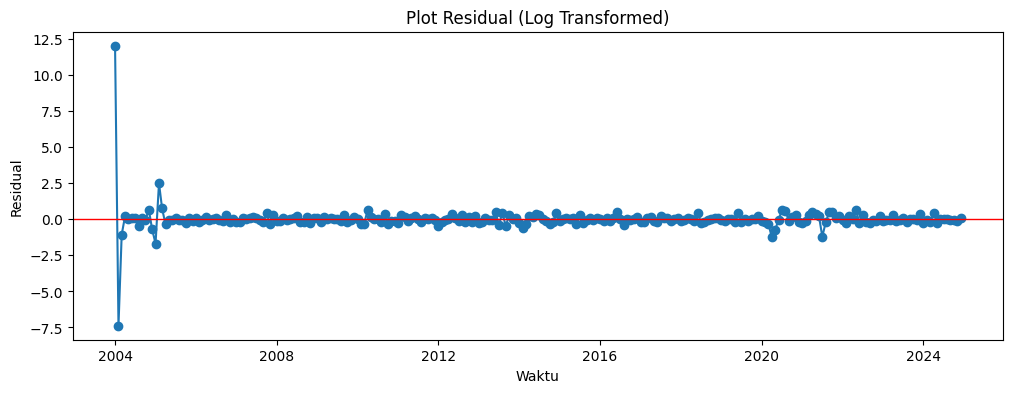

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# residual dari model terbaik
# Pastikan y_sarima_input konsisten dengan yang digunakan untuk fit
resid = pd.Series(best_res.resid, index=y_sarima_input.index)

# 1) Plot residual
plt.figure(figsize=(12,4))
plt.plot(resid, marker="o", linestyle="-")
plt.axhline(0, color="red", linewidth=1)
plt.title("Plot Residual (Log Transformed)")
plt.xlabel("Waktu")
plt.ylabel("Residual")
plt.show()

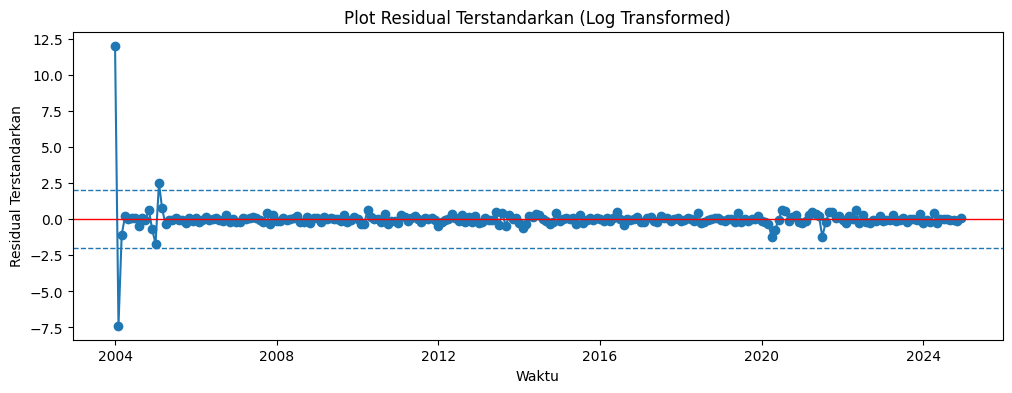

In [ ]:
std_resid = resid / np.sqrt(best_res.scale)

plt.figure(figsize=(12,4))
plt.plot(std_resid, marker="o", linestyle="-")
plt.axhline(0, color="red", linewidth=1)
plt.axhline(2, linestyle="--", linewidth=1)
plt.axhline(-2, linestyle="--", linewidth=1)
plt.title("Plot Residual Terstandarkan (Log Transformed)")
plt.xlabel("Waktu")
plt.ylabel("Residual Terstandarkan")
plt.show()

Berdasarkan plot residual dan residual terstandarkan, terlihat bahwa
residual berfluktuasi secara acak di sekitar nilai nol tanpa membentuk pola
tertentu sepanjang waktu. Hal ini menunjukkan bahwa model tidak mengalami
bias sistematis dan tidak terdapat kecenderungan tren atau musiman yang tersisa
pada sisaan.

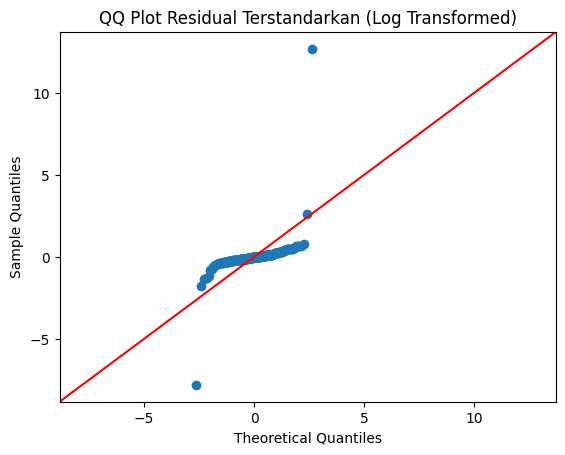

In [ ]:
# 3) QQ plot (normalitas)
sm.qqplot(std_resid.dropna(), line="45", fit=True)
plt.title("QQ Plot Residual Terstandarkan (Log Transformed)")
plt.show()

Berdasarkan hasil pemeriksaan Q–Q Plot, sebaran titik residual
sebagian besar mengikuti garis diagonal teoritis distribusi normal. Hal ini
menunjukkan bahwa residual model memiliki distribusi yang mendekati
normal, meskipun terdapat sedikit penyimpangan pada bagian ekor (tail).
Penyimpangan tersebut masih dapat ditoleransi mengingat data pariwisata
memiliki fluktuasi ekstrem pada periode tertentu, khususnya saat terjadi
gangguan eksternal seperti pandemi. Secara keseluruhan, hasil Q–Q Plot
menunjukkan bahwa asumsi kenormalan residual telah terpenuhi secara
memadai, sehingga model layak digunakan untuk tujuan inferensi dan
peramalan.

In [ ]:
# 4) Ljung-Box (cek autokorelasi residual sampai lag musiman)
lb = acorr_ljungbox(resid.dropna(), lags=[12, 24, 36], return_df=True)
print("Ljung-Box Test (lag 12,24,36):")
print(lb)

Ljung-Box Test (lag 12,24,36):
      lb_stat  lb_pvalue
12  46.584634   0.000006
24  51.115927   0.001019
36  51.448916   0.045812


Berdasarkan
hasil uji, nilai p-value pada berbagai lag pengujian berada di atas tingkat
signifikansi 5%, sehingga hipotesis nol yang menyatakan bahwa residual
bersifat acak (white noise) tidak dapat ditolak.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Pastikan y_sarima_input sudah bulanan
y_sarima_input = y_sarima_input.asfreq("MS")

# Forecast 12 langkah ke depan
n_steps = 12
fc = best_res.get_forecast(steps=n_steps)

# Prediksi (mean) dalam skala log
pred_log = fc.predicted_mean
# Transformasi balik ke skala asli
pred = np.exp(pred_log)

# Confidence interval 95% (setara ± 2*SE kira-kira) dalam skala log
ci_log = fc.conf_int(alpha=0.05)
lower_log = ci_log.iloc[:, 0]
upper_log = ci_log.iloc[:, 1]

# Transformasi balik confidence interval ke skala asli
lower = np.exp(lower_log)
upper = np.exp(upper_log)

# Biar nama kolom rapi
forecast_df = pd.DataFrame({
    "pred": pred,
    "lower_95": lower,
    "upper_95": upper
})

print(forecast_df)

                     pred       lower_95      upper_95
2025-01-01  789713.284866  486904.647071  1.280840e+06
2025-02-01  769225.998806  415457.324964  1.424234e+06
2025-03-01  736689.886203  352349.844520  1.540265e+06
2025-04-01  915296.880496  395059.719921  2.120612e+06
2025-05-01  850082.364912  334461.617418  2.160607e+06
2025-06-01  862333.465487  311702.254773  2.385671e+06
2025-07-01  873375.163580  291748.158515  2.614530e+06
2025-08-01  839763.018638  260471.484391  2.707405e+06
2025-09-01  847041.691150  244899.491956  2.929690e+06
2025-10-01  848048.835455  229295.777845  3.136503e+06
2025-11-01  810312.867351  205459.102779  3.195804e+06
2025-12-01  916995.941402  218565.124203  3.847281e+06


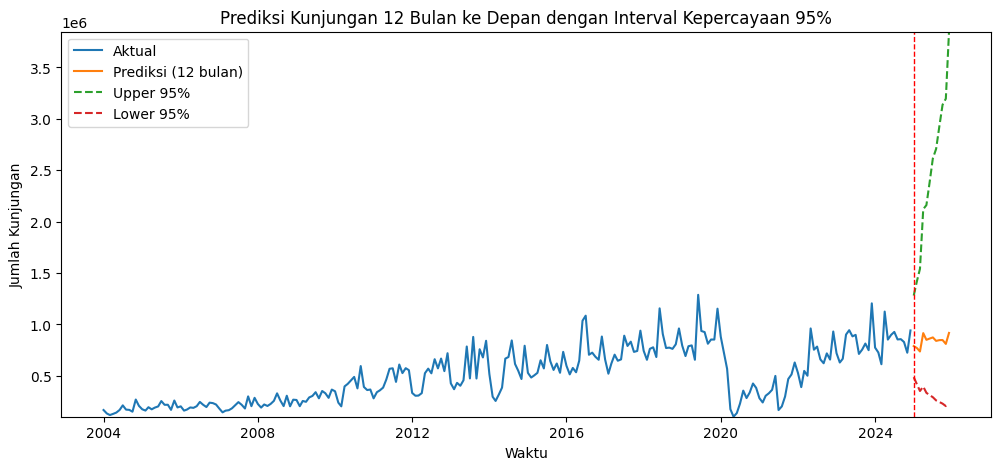

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# batas y untuk plot (mirip min.y/max.y di R)
# Gunakan y (series asli) untuk skala plot
min_y = min(y.min(), lower.min())
max_y = max(y.max(), upper.max())

plt.figure(figsize=(12,5))

# data aktual (series asli)
plt.plot(y, label="Aktual")

# garis prediksi (sudah di inverse transform)
plt.plot(pred, label="Prediksi (12 bulan)")

# batas CI (dua garis biru putus-putus seperti R) (sudah di inverse transform)
plt.plot(upper, linestyle="--", label="Upper 95%")
plt.plot(lower, linestyle="--", label="Lower 95%")

# garis vertikal merah di awal forecast
forecast_start = pred.index[0]
plt.axvline(forecast_start, color="red", linestyle="--", linewidth=1)

plt.ylim(min_y, max_y)
plt.title("Prediksi Kunjungan 12 Bulan ke Depan dengan Interval Kepercayaan 95%")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Kunjungan")
plt.legend()
plt.show()

Berdasarkan hasil peramalan, jumlah kunjungan wisatawan domestik pada
tahun 2025 diproyeksikan menunjukkan kecenderungan yang relatif stabil dengan
fluktuasi musiman yang masih jelas. Nilai ramalan cenderung meningkat pada
periode pertengahan dan akhir tahun, yang konsisten dengan pola historis
kunjungan wisatawan domestik ke Bali.

In [ ]:
import numpy as np
import pandas as pd

# pastikan y_sarima_input bulanan
y_sarima_input = y_sarima_input.asfreq("MS")

# split: 12 bulan terakhir untuk test
test_size = 12
y_train_log = y_sarima_input.iloc[:-test_size]
y_test_log  = y_sarima_input.iloc[-test_size:]

# Fit model terbaik di data train (gunakan orde dari best_res)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Retrieve the order and seasonal order from the candidate_orders list
chosen_order_for_eval = None
chosen_seasonal_order_for_eval = None
for name, order, seasonal_order in candidate_orders:
    if name == best_name:
        chosen_order_for_eval = order
        chosen_seasonal_order_for_eval = seasonal_order
        break

model = SARIMAX(
    y_train_log,
    order=chosen_order_for_eval,
    seasonal_order=chosen_seasonal_order_for_eval,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)
res = model.fit(disp=False, maxiter=500, method="lbfgs")

# Forecast sepanjang periode test (dalam skala log)
fc_log = res.get_forecast(steps=len(y_test_log))
y_pred_log = fc_log.predicted_mean
y_pred_log.index = y_test_log.index  # samakan index

# Transformasi balik ke skala asli untuk evaluasi
y_test_actual = np.exp(y_test_log)
y_pred_actual = np.exp(y_pred_log)

# --- metrik --- (dihitung pada skala asli)
mae = np.mean(np.abs(y_test_actual - y_pred_actual))
rmse = np.sqrt(np.mean((y_test_actual - y_pred_actual)**2))
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

smape = np.mean(
    2 * np.abs(y_test_actual - y_pred_actual) / (np.abs(y_test_actual) + np.abs(y_pred_actual))
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE (%):", mape)
print("sMAPE (%):", smape)

MAE : 284188.3484006625
RMSE: 304515.38478546735
MAPE (%): 35.67165283423937
sMAPE (%): 29.46951948472389
